# Comparación de Redes Elman y Jordan para Clasificación de Texto
En este notebook entrenamos y comparamos una RNN de tipo Elman y una de tipo Jordan sobre el dataset IMDb de análisis de sentimiento. Utilizaremos BPTT (desenrollado manual de la celda RNN) y visualizaremos el desempeño.

In [1]:
# Instalación de librerías adicionales
!pip install datasets -q

In [2]:
# Importar las librerías necesarias
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter
from tqdm import tqdm
import random
import math

c:\Users\jpach\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
SEED = 666

In [4]:
# Descargar IMDb y preparar vocabulario
# Usaremos solo 5000 ejemplos de entrenamiento y 1000 de prueba para rapidez.
dataset = load_dataset("imdb")
train_raw = dataset["train"].shuffle(seed=SEED).select(range(5000))
test_raw = dataset["test"].shuffle(seed=SEED).select(range(1000))

# Tokenizador simple: espacios y puntuación
def simple_tokenizer(text):
    text = text.lower()
    # Reemplazar signos de puntuación por espacio
    for ch in ['.', ',', '!', '?', '"', "'", '(', ')', '[', ']', '{', '}', ':', ';', '-', '/', '<', '>']:
        text = text.replace(ch, ' ')
    return text.split()

# Construir vocabulario
counter = Counter()
for example in train_raw:
    tokens = simple_tokenizer(example["text"])
    counter.update(tokens)

# Añadir tokens especiales
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word, freq in counter.most_common(9998):  # dejamos espacio para los dos especiales
    word2idx[word] = len(word2idx)

vocab_size = len(word2idx)
print(f"Tamaño del vocabulario: {vocab_size}")

Tamaño del vocabulario: 10000


In [5]:
# Dataset y DataLoader
class IMDBDataset(Dataset):
    def __init__(self, data, word2idx):
        self.data = data
        self.word2idx = word2idx

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data[idx]["text"]
        label = self.data[idx]["label"]
        tokens = simple_tokenizer(text)
        ids = [self.word2idx.get(tok, self.word2idx[UNK_TOKEN]) for tok in tokens]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

def collate_fn(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in sequences])
    padded = pad_sequence(sequences, batch_first=True, padding_value=0)  # 0 = PAD
    return padded, torch.stack(labels), lengths

train_dataset = IMDBDataset(train_raw, word2idx)
test_dataset = IMDBDataset(test_raw, word2idx)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [6]:
# Definición de los modelos (proporcionados en la pregunta)

class ElmanRNNCellClassifier(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int, hidden_dim: int, num_classes: int, pad_idx: int = 0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.rnn_cell = nn.RNNCell(emb_dim, hidden_dim, nonlinearity="tanh")
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.hidden_dim = hidden_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [batch, time]
        batch, steps = x.shape
        emb = self.embedding(x)  # [batch, time, emb_dim]
        h = emb.new_zeros(batch, self.hidden_dim)
        for t in range(steps):
            h = self.rnn_cell(emb[:, t, :], h)
        return self.fc(h)

class ElmanRNNClassifier(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int, hidden_dim: int, num_classes: int, pad_idx: int = 0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(emb_dim, hidden_dim, batch_first=True, nonlinearity="tanh")
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        emb = self.embedding(x)
        output, h_n = self.rnn(emb)
        return self.fc(h_n[-1])

class JordanRNNCellClassifier(nn.Module):
    """Jordan simplificada: realimenta la salida oculta proyectada del paso anterior."""
    def __init__(self, vocab_size: int, emb_dim: int, hidden_dim: int, num_classes: int, pad_idx: int = 0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.feedback = nn.Linear(num_classes, hidden_dim)
        self.cell = nn.RNNCell(emb_dim + hidden_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.hidden_dim = hidden_dim
        self.num_classes = num_classes

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch, steps = x.shape
        emb = self.embedding(x)
        h = emb.new_zeros(batch, self.hidden_dim)
        y_prev = emb.new_zeros(batch, self.num_classes)
        for t in range(steps):
            context = self.feedback(y_prev)
            h = self.cell(torch.cat([emb[:, t, :], context], dim=-1), h)
            y_prev = self.fc(h)
        return y_prev

In [7]:
# Configuración de hiperparámetros y funciones de entrenamiento/evaluación
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
emb_dim = 128
hidden_dim = 128
num_classes = 2
pad_idx = 0

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for x, y, lengths in tqdm(loader, desc="Entrenando", leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=-1)
        correct += (preds == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for x, y, lengths in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=-1)
        correct += (preds == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

def train_model(model, train_loader, test_loader, epochs=10, lr=1e-3):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, epochs+1):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = eval_epoch(model, test_loader, criterion)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch:2d}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
    return history

In [8]:
# Entrenamiento del modelo Elman (con RNNCell, BPTT manual)
print("Entrenando ElmanRNNCellClassifier (BPTT desenrollado manualmente)")
elman_cell = ElmanRNNCellClassifier(vocab_size, emb_dim, hidden_dim, num_classes, pad_idx)
hist_elman_cell = train_model(elman_cell, train_loader, test_loader, epochs=1)

Entrenando ElmanRNNCellClassifier (BPTT desenrollado manualmente)


Epoch  1: train_loss=0.6947, train_acc=0.5036 | val_loss=0.6916, val_acc=0.5380


In [9]:
# Entrenamiento del modelo Jordan (con RNNCell, realimentación de salida)
print("Entrenando JordanRNNCellClassifier")
jordan = JordanRNNCellClassifier(vocab_size, emb_dim, hidden_dim, num_classes, pad_idx)
hist_jordan = train_model(jordan, train_loader, test_loader, epochs=1)

Entrenando JordanRNNCellClassifier


Epoch  1: train_loss=0.7031, train_acc=0.4950 | val_loss=0.6959, val_acc=0.4590


In [10]:
# Entrenamiento del modelo Elman con nn.RNN para comparar
print("Entrenando ElmanRNNClassifier (nn.RNN, BPTT automático)")
elman_builtin = ElmanRNNClassifier(vocab_size, emb_dim, hidden_dim, num_classes, pad_idx)
hist_elman_builtin = train_model(elman_builtin, train_loader, test_loader, epochs=1)

Entrenando ElmanRNNClassifier (nn.RNN, BPTT automático)


Epoch  1: train_loss=0.6939, train_acc=0.5142 | val_loss=0.6912, val_acc=0.5390


In [13]:
print("Elman Cell epochs:", len(hist_elman_cell.get("val_loss", [])))
print("Jordan epochs:", len(hist_jordan.get("val_loss", [])))
print("Elman Built-in epochs:", len(hist_elman_builtin.get("val_loss", [])))

print("Primer valor Elman Cell val_loss:", hist_elman_cell.get("val_loss", [None])[0])

Elman Cell epochs: 1
Jordan epochs: 1
Elman Built-in epochs: 1
Primer valor Elman Cell val_loss: 0.6915590829849243


Épocas disponibles: 1


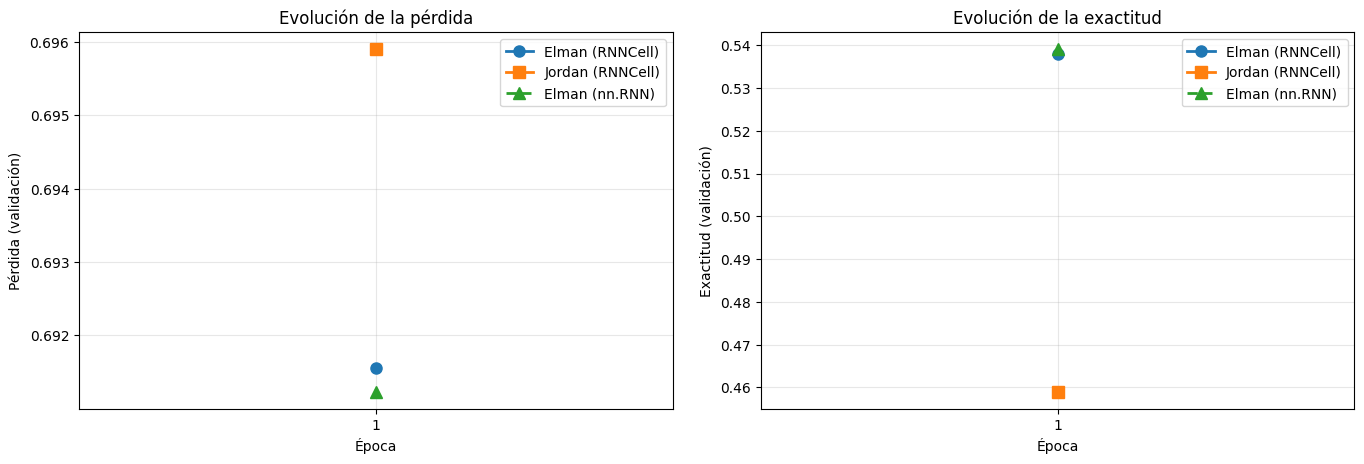

Gráfico generado con éxito.


In [14]:
%matplotlib inline

# 1. Obtener el número real de épocas (todas deben tener al menos 1)
n_epochs = min(len(hist_elman_cell["val_loss"]),
               len(hist_jordan["val_loss"]),
               len(hist_elman_builtin["val_loss"]))

if n_epochs == 0:
    print("No hay datos para graficar.")
else:
    print(f"Épocas disponibles: {n_epochs}")

    # 2. Crear la figura y los ejes
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=100)
    epochs = list(range(1, n_epochs + 1))

    # ---- Pérdida ----
    ax1.plot(epochs, hist_elman_cell["val_loss"][:n_epochs],
             marker='o', markersize=8, linewidth=2, label="Elman (RNNCell)")
    ax1.plot(epochs, hist_jordan["val_loss"][:n_epochs],
             marker='s', markersize=8, linewidth=2, label="Jordan (RNNCell)")
    ax1.plot(epochs, hist_elman_builtin["val_loss"][:n_epochs],
             marker='^', markersize=8, linewidth=2, linestyle="--", label="Elman (nn.RNN)")
    ax1.set_xlabel("Época")
    ax1.set_ylabel("Pérdida (validación)")
    ax1.set_title("Evolución de la pérdida")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # ---- Exactitud ----
    ax2.plot(epochs, hist_elman_cell["val_acc"][:n_epochs],
             marker='o', markersize=8, linewidth=2, label="Elman (RNNCell)")
    ax2.plot(epochs, hist_jordan["val_acc"][:n_epochs],
             marker='s', markersize=8, linewidth=2, label="Jordan (RNNCell)")
    ax2.plot(epochs, hist_elman_builtin["val_acc"][:n_epochs],
             marker='^', markersize=8, linewidth=2, linestyle="--", label="Elman (nn.RNN)")
    ax2.set_xlabel("Época")
    ax2.set_ylabel("Exactitud (validación)")
    ax2.set_title("Evolución de la exactitud")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Si solo hay 1 época, ajustamos los límites para que el punto quede centrado
    if n_epochs == 1:
        ax1.set_xlim(0.5, 1.5)
        ax2.set_xlim(0.5, 1.5)
        ax1.set_xticks([1])
        ax2.set_xticks([1])

    plt.tight_layout(pad=2.0)
    plt.show()
    print("Gráfico generado con éxito.")

## Observaciones sobre BPTT
En las implementaciones `ElmanRNNCellClassifier` y `JordanRNNCellClassifier`, el bucle `for t in range(steps)` desenrolla la red en el tiempo. PyTorch construye automáticamente el grafo de cómputo en cada iteración, y la función `backward()` aplica *Backpropagation Through Time* a través de todos los pasos temporales. Así, aunque no hayamos escrito manualmente las derivadas, el BPTT se ejecuta de forma exacta.

La red `ElmanRNNClassifier` usa `nn.RNN`, que internamente también realiza BPTT (ya sea desenrollado o con algoritmos optimizados), por lo que su entrenamiento es matemáticamente equivalente al de `ElmanRNNCellClassifier`. Las diferencias que puedas observar se deben al muestreo aleatorio y a la inicialización, no al método de cálculo de gradientes.

In [ ]:
# Pequeño ejemplo de inferencia para comprobar
def predict_sentiment(model, sentence, word2idx):
    model.eval()
    tokens = simple_tokenizer(sentence)
    ids = [word2idx.get(tok, 1) for tok in tokens]  # 1 = <unk>
    x = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        pred = logits.argmax(dim=-1).item()
    return "positivo" if pred == 1 else "negativo"

print("Prueba Jordan:")
print(predict_sentiment(jordan, "This movie was fantastic, I loved it", word2idx))
print(predict_sentiment(jordan, "Terrible film, waste of time", word2idx))

print("Prueba Elman (Cell):")
print(predict_sentiment(elman_cell, "This movie was fantastic, I loved it", word2idx))
print(predict_sentiment(elman_cell, "Terrible film, waste of time", word2idx))